In [9]:
import numpy as np

from tools.surface_code import generate_steane_circuit
from tools.error_models import construct_bit_flip_model 
from tools.log_error_rate import generate_log_error_rates, count_logical_errors_using_MWPM, count_logical_errors_ML,  gen_error_model_count_logical_error_MWPM 

In [10]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/new_start/tools/graphics.py'>

In [11]:
# Global parameters
distances = [3,5]
rounds = 1
noise_set = np.logspace(-2,-0.9, num=10)
num_shots = 100_000

steane_circuits = [generate_steane_circuit(d,rounds=rounds) for d in distances]
error_func = construct_bit_flip_model

In [12]:
# ML
count_logical_func = count_logical_errors_ML


log_error_rates_ML, y_errs_ML = generate_log_error_rates(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
)

In [13]:
# MWMP (Basic Noise)
count_logical_func = gen_error_model_count_logical_error_MWPM("bit_flip")


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
)

In [14]:
# MWPM all knowing using_MWPM 

# special_circ
steane_circuits_no_ft = [generate_steane_circuit(d,rounds=rounds,ft_stab_detector=False) for d in distances]


log_error_rates_MWPM_AK, y_errs_MWPM_AK = generate_log_error_rates(
    steane_circuits_no_ft,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
)

<Figure size 640x480 with 0 Axes>

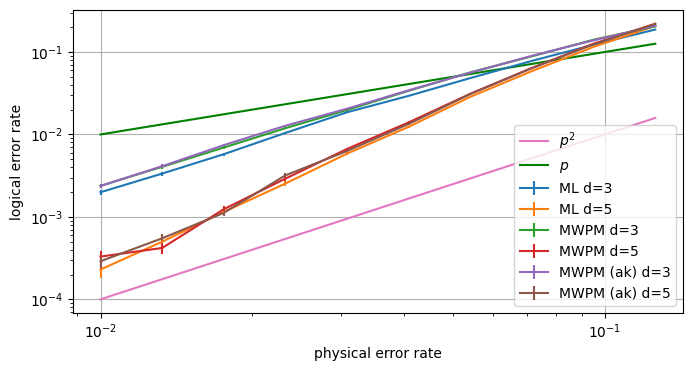

In [15]:
graphic.overlay_different_slopes(
    [log_error_rates_ML, log_error_rates_MWPM, log_error_rates_MWPM_AK],
    [y_errs_ML, y_errs_MWPM, y_errs_MWPM_AK],
    distances=distances,
    noise_set=noise_set,
    titles=["ML", "MWPM", "MWPM (ak)"],
    reference_lines=True,
)

<Figure size 640x480 with 0 Axes>

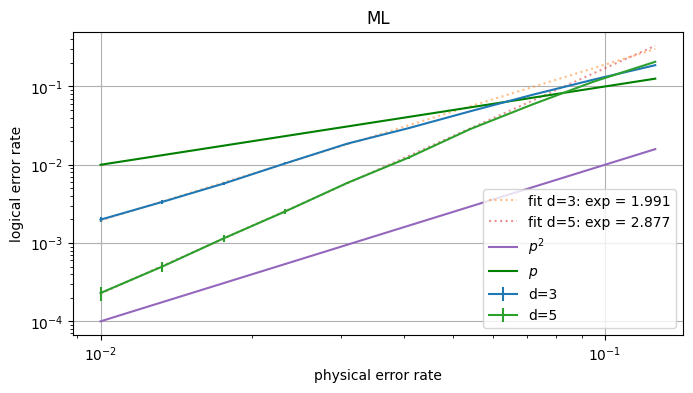

<Figure size 640x480 with 0 Axes>

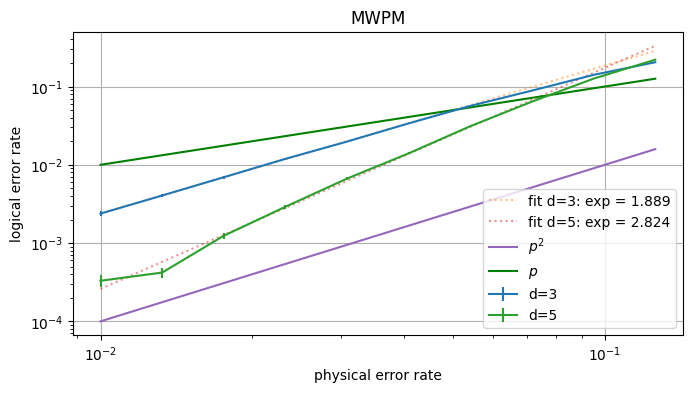

<Figure size 640x480 with 0 Axes>

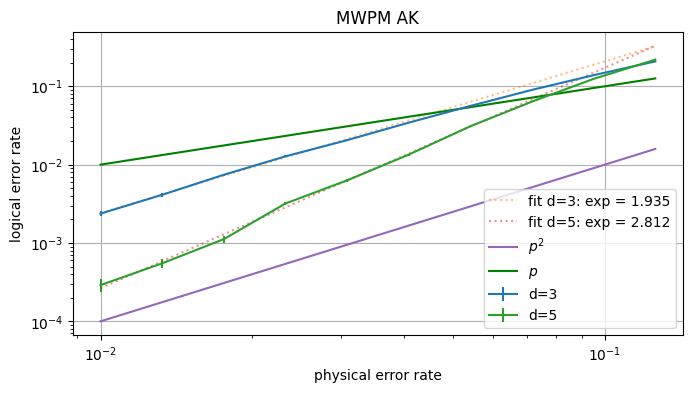

In [16]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM_AK,
        y_errs_MWPM_AK,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM AK"
    ) 